# Differential Equations Examples

Differential equations model the dynamics of physical systems. This notebook covers:
- Analytical ODE solving with SymPy
- Numerical integration with SciPy
- Direction fields, phase portraits, and transfer functions
- Examples relevant to control engineering

In [1]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

print(f"SymPy version: {sp.__version__}")
print(f"NumPy version: {np.__version__}")

SymPy version: 1.14.0
NumPy version: 2.4.6


## 1. First-Order ODEs

Solve $\frac{dy}{dt} + 2 y = e^{-t}$ with $y(0) = 1$.

In [2]:
t = sp.symbols('t')
y = sp.Function('y')

# Define ODE: y' + 2y = exp(-t)
ode1 = sp.Eq(sp.diff(y(t), t) + 2*y(t), sp.exp(-t))
print("ODE:", ode1)

# Solve analytically
sol1 = sp.dsolve(ode1, y(t), ics={y(0): 1})
print("Solution:", sol1)

ODE: Eq(2*y(t) + Derivative(y(t), t), exp(-t))
Solution: Eq(y(t), exp(-t))


## 2. Second-Order ODE (Mass-Spring-Damper)

A classic control system: $m\ddot{x} + b\dot{x} + kx = 0$.

In [3]:
m, b, k = sp.symbols('m b k', positive=True)
x = sp.Function('x')

ode2 = sp.Eq(m*sp.diff(x(t), t, 2) + b*sp.diff(x(t), t) + k*x(t), 0)
print("Mass-spring-damper ODE:", ode2)

sol2 = sp.dsolve(ode2, x(t))
print("General solution:", sol2)

# Overdamped case: m=1, b=5, k=4 => roots -1, -4
sol_num = sp.dsolve(
    ode2.subs({m: 1, b: 5, k: 4}), x(t),
    ics={x(0): 1, sp.diff(x(t), t).subs(t, 0): 0}
)
print("\nOverdamped (m=1, b=5, k=4):", sol_num)

Mass-spring-damper ODE: Eq(b*Derivative(x(t), t) + k*x(t) + m*Derivative(x(t), (t, 2)), 0)
General solution: Eq(x(t), C1*exp(t*(-b + sqrt(b**2 - 4*k*m))/(2*m)) + C2*exp(-t*(b + sqrt(b**2 - 4*k*m))/(2*m)))

Overdamped (m=1, b=5, k=4): Eq(x(t), (4/3 - exp(-3*t)/3)*exp(-t))


## 3. Systems of ODEs

A two-state system: $\dot{x}_1 = -2x_1 + x_2$, $\dot{x}_2 = x_1 - 2x_2$.

In [4]:
x1 = sp.Function('x1')
x2 = sp.Function('x2')

eq1 = sp.Eq(sp.diff(x1(t), t), -2*x1(t) + x2(t))
eq2 = sp.Eq(sp.diff(x2(t), t), x1(t) - 2*x2(t))

sol_sys = sp.dsolve([eq1, eq2], ics={x1(0): 5, x2(0): 1})
print("x1(t):", sol_sys[0])
print("x2(t):", sol_sys[1])

x1(t): Eq(x1(t), 3*exp(-t) + 2*exp(-3*t))
x2(t): Eq(x2(t), 3*exp(-t) - 2*exp(-3*t))


## 4. Numerical Integration with SciPy

When analytical solutions are impractical, use `solve_ivp`. Consider the nonlinear pendulum:
$\ddot{\theta} + \sin(\theta) = 0$.

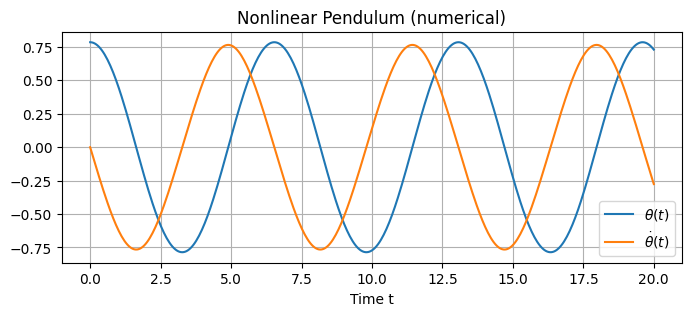

In [5]:
def pendulum(t, y):
    theta, omega = y
    dtheta = omega
    domega = -np.sin(theta)
    return [dtheta, domega]

t_span = (0, 20)
y0 = [np.pi/4, 0.0]  # start at 45°, released from rest
sol_num = solve_ivp(pendulum, t_span, y0, max_step=0.05)

plt.figure(figsize=(8, 3))
plt.plot(sol_num.t, sol_num.y[0], label=r'$\theta(t)$')
plt.plot(sol_num.t, sol_num.y[1], label=r'$\dot{\theta}(t)$')
plt.xlabel('Time t')
plt.legend()
plt.title('Nonlinear Pendulum (numerical)')
plt.grid(True)
plt.show()

## 5. Direction Field (Slope Field)

Visualize the behaviour of $\dot{y} = -y + \sin(t)$.

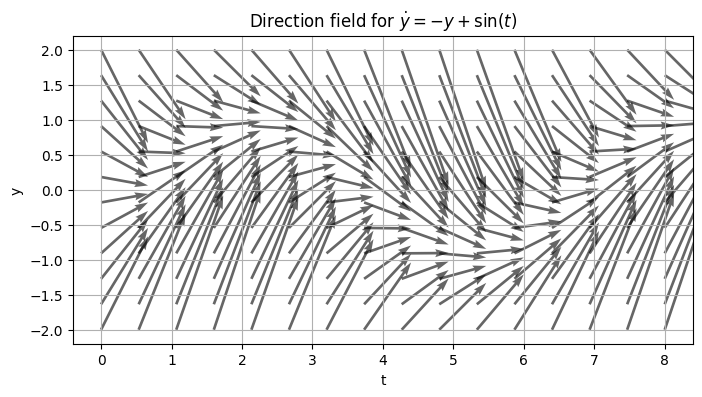

In [6]:
Y, T = np.meshgrid(np.linspace(-2, 2, 12), np.linspace(0, 8, 16))
dY = -Y + np.sin(T)
dT = np.ones_like(T)

plt.figure(figsize=(8, 4))
plt.quiver(T, Y, dT, dY, angles='xy', scale_units='xy', scale=1.5, alpha=0.6)
plt.xlabel('t')
plt.ylabel('y')
plt.title(r"Direction field for $\dot{y} = -y + \sin(t)$")
plt.grid(True)
plt.show()

## 6. Phase Portrait (2D System)

Phase portrait of the linear system $\dot{\mathbf{x}} = A\mathbf{x}$ with $A = \begin{bmatrix} 0 & 1 \\ -2 & -3 \end{bmatrix}$.

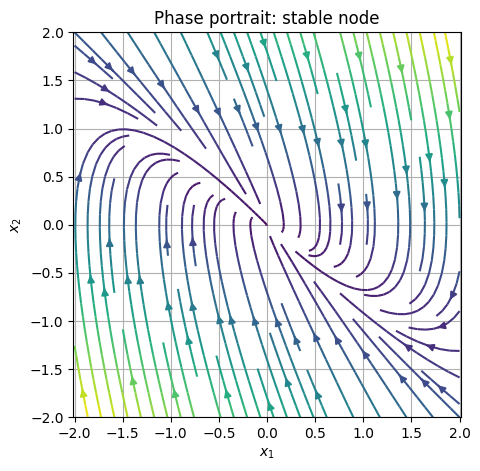

In [7]:
A = np.array([[0, 1], [-2, -3]])

# Grid of initial states
x1_vals = np.linspace(-2, 2, 11)
x2_vals = np.linspace(-2, 2, 11)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

U = A[0, 0]*X1 + A[0, 1]*X2
V = A[1, 0]*X1 + A[1, 1]*X2

plt.figure(figsize=(5, 5))
plt.streamplot(X1, X2, U, V, color=np.sqrt(U**2 + V**2), cmap='viridis')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title('Phase portrait: stable node')
plt.grid(True)
plt.axis('equal')
plt.show()

## 7. Transfer Function from ODE

Given $\ddot{y} + 3\dot{y} + 2y = \dot{u} + u$, find the transfer function $G(s) = \frac{Y(s)}{U(s)}$.

In [8]:
s, Y, U = sp.symbols('s Y U')

# Laplace transform of ODE (zero ICs): s^2 Y + 3s Y + 2Y = s U + U
eq = sp.Eq(s**2*Y + 3*s*Y + 2*Y, s*U + U)
G = sp.solve(eq, Y)[0] / U
G_simplified = sp.simplify(G)
print("G(s) =", G_simplified)

# Partial fraction decomposition
G_pf = sp.apart(G_simplified, s)
print("Partial fractions:", G_pf)

G(s) = 1/(s + 2)
Partial fractions: 1/(s + 2)


## 8. Step Response via Inverse Laplace

For $G(s) = \frac{1}{s^2 + 3s + 2}$, compute the step response $y(t)$.

In [9]:
G1 = 1 / (s**2 + 3*s + 2)

# Step input: U(s) = 1/s => Y(s) = G(s)/s
Y_s = G1 / s
print("Y(s) =", Y_s)

# Expand for clean inverse transform
Y_expanded = sp.apart(Y_s, s)
print("Partial fractions:", Y_expanded)

# Inverse Laplace
y_t = sp.inverse_laplace_transform(Y_s, s, t)
print("\ny(t) =", y_t)

Y(s) = 1/(s*(s**2 + 3*s + 2))
Partial fractions: 1/(2*(s + 2)) - 1/(s + 1) + 1/(2*s)

y(t) = Heaviside(t)/2 - exp(-t)*Heaviside(t) + exp(-2*t)*Heaviside(t)/2


## 9. Numerical Step Response

Simulate $G(s) = \frac{1}{s^2 + 3s + 2}$ using `solve_ivp` in state-space form.

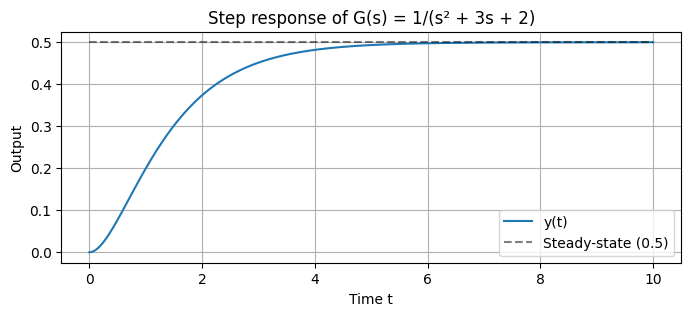

In [10]:
def step_system(t, x):
    # State-space: x = [y, dy/dt]
    # u(t) = 1 for step
    u = 1.0
    y, dy = x
    ddy = -3*dy - 2*y + u
    return [dy, ddy]

res = solve_ivp(step_system, (0, 10), [0.0, 0.0], max_step=0.01)

plt.figure(figsize=(8, 3))
plt.plot(res.t, res.y[0], label='y(t)')
plt.plot(res.t, np.ones_like(res.t)*0.5, 'k--', alpha=0.5, label='Steady-state (0.5)')
plt.xlabel('Time t')
plt.ylabel('Output')
plt.title('Step response of G(s) = 1/(s² + 3s + 2)')
plt.legend()
plt.grid(True)
plt.show()